# CF attribute analysis
- Load the calculated attributes from C2's input data
- C2_DATA doesnt have the cf information so we need to use the fold data
- Analyse how they are distributed in correct vs incorrect predictions

> We are workign in the new split - cross fold validation on the C0 held out set

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

In [3]:
# Load c2 data
cf16_fold0_data = pd.read_csv("/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results_extended/cf_16/fold_0_predictions.csv")
cf16_fold1_data = pd.read_csv("/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results_extended/cf_16/fold_1_predictions.csv")
cf16_fold2_data = pd.read_csv("/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results_extended/cf_16/fold_2_predictions.csv")
cf16_fold3_data = pd.read_csv("/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results_extended/cf_16/fold_3_predictions.csv")
cf16_fold4_data = pd.read_csv("/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results_extended/cf_16/fold_4_predictions.csv")


In [4]:
# Pool the folds together
cf16_merged_data = pd.concat([cf16_fold0_data, cf16_fold1_data, cf16_fold2_data, cf16_fold3_data, cf16_fold4_data], ignore_index=True)

In [5]:
cf16_merged_data

,path,effusion_prob,effusion_true,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,RF_B1_prob,RF_B2_prob,RF_B4_prob,RF_M3_prob,RF_M6_prob,MLP_B1_prob,MLP_B2_prob,MLP_B4_prob,MLP_M3_prob,MLP_M6_prob
0,CheXpert-v1.0-small/train/patient00008/study1/...,0.989891,1.0,-0.001258,-0.002981,0.004603,0.001782,0.038358,0.399419,-0.001282,...,1.00,0.895,0.925,0.965,0.990,0.980743,0.927671,0.984335,1.0,1.000000
1,CheXpert-v1.0-small/train/patient00008/study2/...,0.803473,1.0,-0.001191,-0.002815,0.002819,0.001348,0.057667,0.703849,-0.001344,...,0.99,0.880,0.915,0.945,0.945,0.904083,0.889738,0.723830,1.0,1.000000
2,CheXpert-v1.0-small/train/patient00010/study1/...,0.022443,0.0,-0.001185,-0.000544,0.002301,0.005169,-0.117937,-0.033050,-0.001290,...,1.00,0.950,0.960,0.930,0.960,0.949739,0.837278,0.965281,1.0,1.000000
3,CheXpert-v1.0-small/train/patient00012/study2/...,0.061503,0.0,-0.001186,-0.001272,0.003885,0.003653,-0.103996,0.122837,-0.001299,...,0.97,0.910,0.855,0.965,0.970,0.898363,0.897815,0.958778,1.0,0.999796
4,CheXpert-v1.0-small/train/patient00012/study1/...,0.029165,0.0,-0.001169,-0.001557,0.002562,0.004091,-0.134545,0.211838,-0.001316,...,1.00,0.940,0.965,0.980,0.995,0.943117,0.905704,0.975798,1.0,0.999998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45150,CheXpert-v1.0-small/train/patient47326/study15...,0.991323,1.0,-0.001218,-0.002772,0.004868,0.001912,0.038572,0.362541,-0.001303,...,1.00,0.975,0.980,0.990,1.000,0.979770,0.994820,0.988421,1.0,0.999999
45151,CheXpert-v1.0-small/train/patient47326/study16...,0.997699,1.0,-0.001202,-0.003193,0.004110,0.002293,0.003134,0.662992,-0.001271,...,1.00,0.970,0.985,0.985,1.000,0.980806,0.988997,0.990673,1.0,0.999999
45152,CheXpert-v1.0-small/train/patient47326/study6/...,0.994333,1.0,-0.001193,-0.002723,0.003124,0.002845,0.046595,0.291322,-0.001343,...,1.00,0.950,0.955,0.960,0.950,0.980266,0.930624,0.983894,1.0,1.000000
45153,CheXpert-v1.0-small/train/patient47326/study14...,0.991939,1.0,-0.001210,-0.003301,0.006024,0.002212,0.097969,0.434269,-0.001248,...,1.00,0.955,0.975,0.980,0.990,0.979873,0.982837,0.983728,1.0,1.000000


In [6]:
# Check columns
for column in cf16_merged_data.columns:
    print(column)

path
effusion_prob
effusion_true
emb_0
emb_1
emb_2
emb_3
emb_4
emb_5
emb_6
emb_7
emb_8
emb_9
emb_10
emb_11
emb_12
emb_13
emb_14
emb_15
emb_16
emb_17
emb_18
emb_19
emb_20
emb_21
emb_22
emb_23
emb_24
emb_25
emb_26
emb_27
emb_28
emb_29
emb_30
emb_31
emb_32
emb_33
emb_34
emb_35
emb_36
emb_37
emb_38
emb_39
emb_40
emb_41
emb_42
emb_43
emb_44
emb_45
emb_46
emb_47
emb_48
emb_49
emb_50
emb_51
emb_52
emb_53
emb_54
emb_55
emb_56
emb_57
emb_58
emb_59
emb_60
emb_61
emb_62
emb_63
emb_64
emb_65
emb_66
emb_67
emb_68
emb_69
emb_70
emb_71
emb_72
emb_73
emb_74
emb_75
emb_76
emb_77
emb_78
emb_79
emb_80
emb_81
emb_82
emb_83
emb_84
emb_85
emb_86
emb_87
emb_88
emb_89
emb_90
emb_91
emb_92
emb_93
emb_94
emb_95
emb_96
emb_97
emb_98
emb_99
emb_100
emb_101
emb_102
emb_103
emb_104
emb_105
emb_106
emb_107
emb_108
emb_109
emb_110
emb_111
emb_112
emb_113
emb_114
emb_115
emb_116
emb_117
emb_118
emb_119
emb_120
emb_121
emb_122
emb_123
emb_124
emb_125
emb_126
emb_127
emb_128
emb_129
emb_130
emb_131
emb_132
emb_133
emb_1

In [7]:
DISEASE = 'effusion'

META_COLS = {
    f'{DISEASE}_prob', f'{DISEASE}_pred', f'{DISEASE}_true',
    'correct', 'path', 'patient_id', 'cf_prob', 'cf_paths', 'margin'
}

ORGANS = [
    "Left Lung", "Right Lung", "Heart", "Mediastinum",
    "Facies Diaphragmatica", "Aorta", "Left Hilus Pulmonis",
    "Right Hilus Pulmonis", "Left Scapula", "Right Scapula",
    "Left Clavicle", "Right Clavicle", "Weasand", "Spine"
]

FEATURE_TYPES = {
    'shape2D': ['shape2D'],
    'firstorder': ['firstorder'],
    'geometric': ['area_pixels', 'bbox', 'perimeter'],
    'texture': ['glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
}

def build_categories(columns):

    categories = {}

    for col in columns:

        # label metadata columns but DO NOT skip them
        if col in META_COLS:
            prefix = 'META'
        else:
            prefix = 'Delta' if col.startswith('delta_') else 'Original'

        # find organ
        organ = next((o for o in ORGANS if o in col), 'Global')

        # find feature type
        feature_type = 'other'

        for ftype, keywords in FEATURE_TYPES.items():
            if any(k in col for k in keywords):
                feature_type = ftype
                break

        # build category name
        category = f"{prefix} | {organ} | {feature_type}"

        categories.setdefault(category, []).append(col)

    return categories


# build categories
feature_cols = [
    c for c in cf16_merged_data.columns
    if c not in META_COLS
]

categories = build_categories(feature_cols)



## Statistical analysis

In [7]:
total_features = sum(len(cols) for cols in categories.values())
print(f"Total features: {total_features}")
print(f"Total categories: {len(categories)}")
for cat, cols in categories.items():
    print(f"  {cat}: {len(cols)} features")

Total features: 2634
Total categories: 114
  Original | Global | other: 1052 features
  Original | Aorta | geometric: 5 features
  Original | Aorta | firstorder: 18 features
  Original | Aorta | texture: 24 features
  Original | Aorta | shape2D: 9 features
  Original | Facies Diaphragmatica | geometric: 5 features
  Original | Facies Diaphragmatica | firstorder: 18 features
  Original | Facies Diaphragmatica | texture: 24 features
  Original | Facies Diaphragmatica | shape2D: 9 features
  Original | Heart | geometric: 5 features
  Original | Heart | firstorder: 18 features
  Original | Heart | texture: 24 features
  Original | Heart | shape2D: 9 features
  Original | Left Clavicle | geometric: 5 features
  Original | Left Clavicle | firstorder: 18 features
  Original | Left Clavicle | texture: 24 features
  Original | Left Clavicle | shape2D: 9 features
  Original | Left Hilus Pulmonis | geometric: 5 features
  Original | Left Hilus Pulmonis | firstorder: 18 features
  Original | Left 

In [10]:
# Create a subdf that only has the delta features
delta_cols = [col for col in cf16_merged_data.columns if col.startswith('delta_')]
delta_df = cf16_merged_data[delta_cols + ['correct']]


In [8]:
def plot_category(df, category_name, feature_cols, correct_col='correct', max_cols=6):
    """
    Boxplot of all features in a category, split by correct vs incorrect.
    Wraps into multiple rows if there are more than max_cols features.
    """
    
    if len(feature_cols) > 50:
        print(f"Skipping {category_name} — too many features ({len(feature_cols)})")
        return
    
    n_features = len(feature_cols)
    n_cols = min(n_features, max_cols)
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 4 * n_rows))
    
    # Always make axes a flat array for easy indexing
    axes = np.array(axes).flatten()
    
    correct_mask   = df[correct_col] == 1
    incorrect_mask = df[correct_col] == 0
    
    for i, col in enumerate(feature_cols):
        ax = axes[i]
        
        data_correct   = df.loc[correct_mask,   col].dropna().values
        data_incorrect = df.loc[incorrect_mask, col].dropna().values
        
        ax.boxplot(
            [data_correct, data_incorrect],
            labels=['Correct', 'Incorrect'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
        )
        
        # Clip y-axis at 99th percentile
        p99 = np.nanpercentile(np.concatenate([data_correct, data_incorrect]), 99)
        ax.set_ylim(bottom=None, top=p99 * 1.1)
        
        short_name = col.split('_')[-1]
        ax.set_title(short_name, fontsize=8)
        ax.tick_params(axis='x', labelsize=7)
    
    # Hide any unused subplots (when n_features doesn't fill the grid)
    for j in range(n_features, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(category_name, fontsize=11)
    plt.tight_layout()
    plt.show()
    

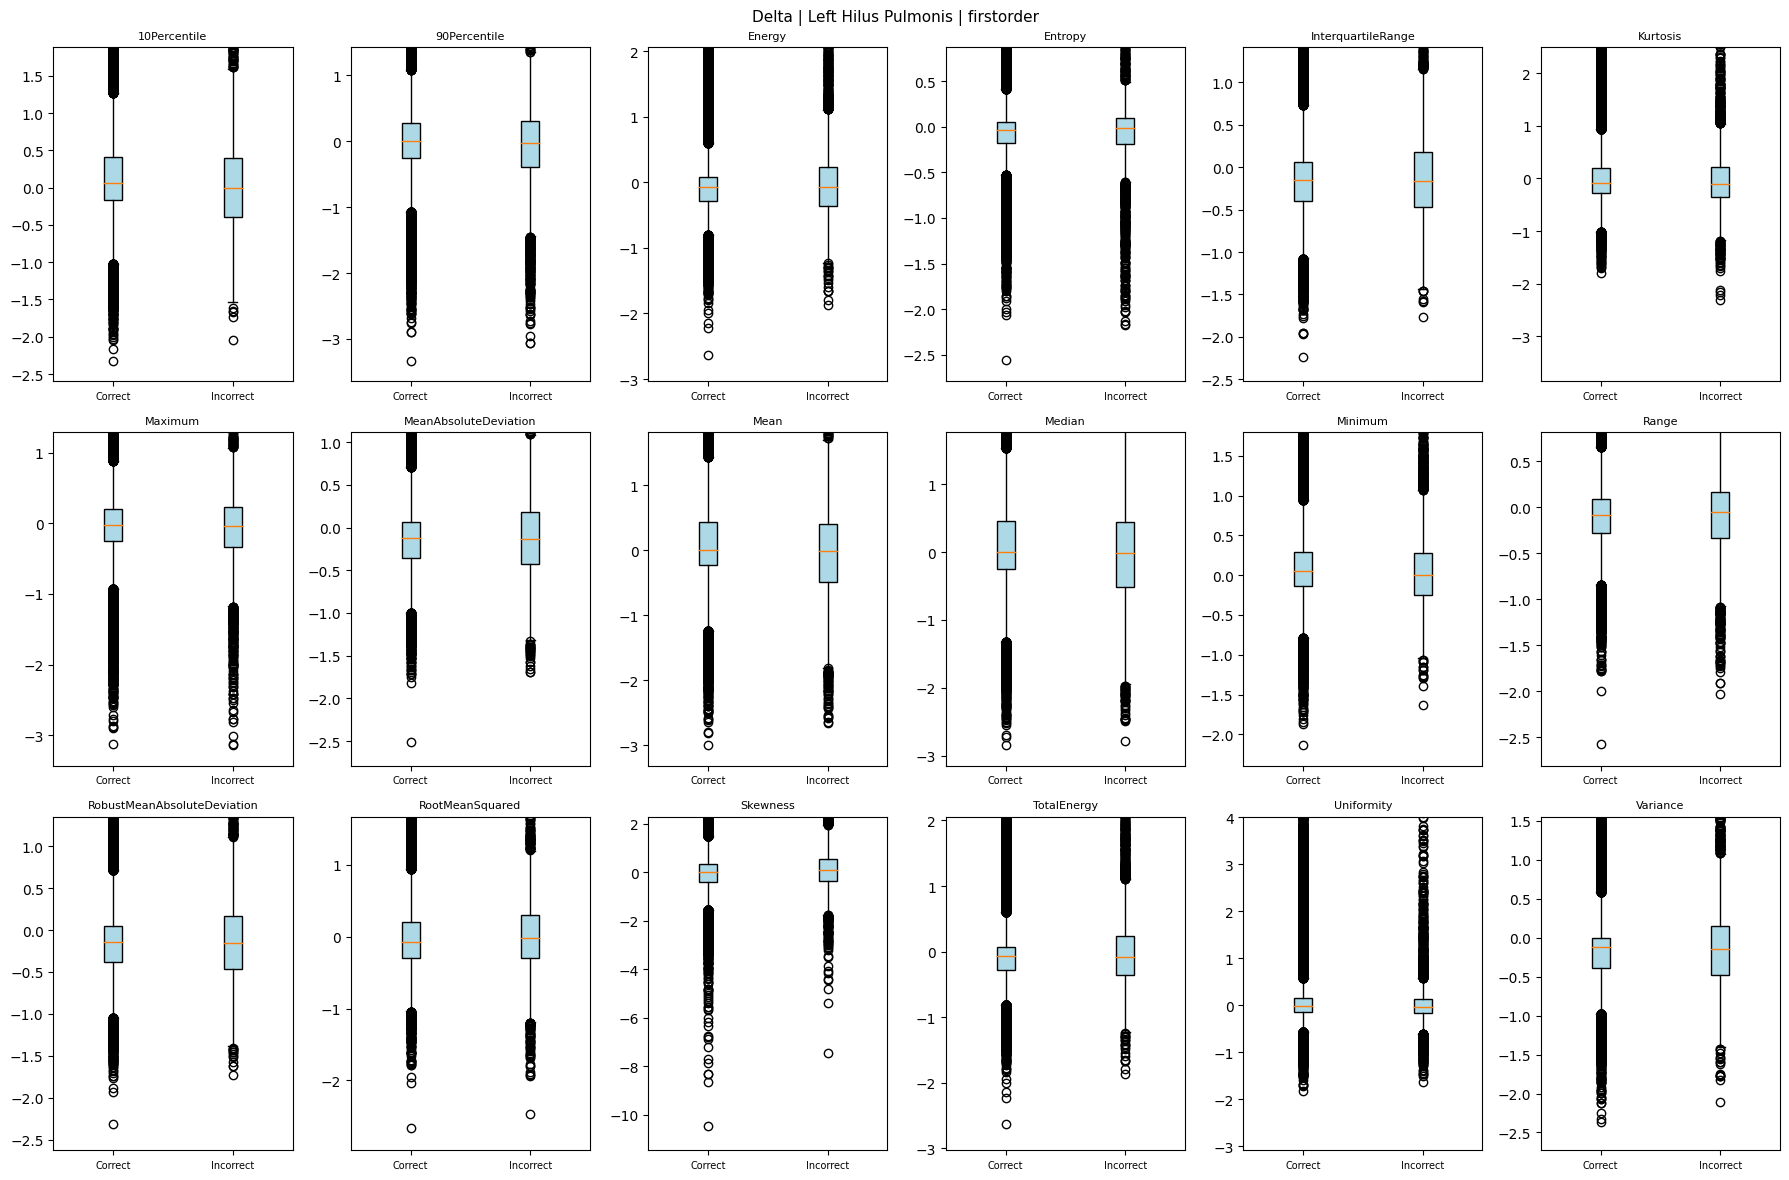

In [21]:
# Example: plot one 
example_category = "Delta | Left Hilus Pulmonis | firstorder"
plot_category(cf16_merged_data, example_category, categories[example_category])

# LDA - Linear Discriminant Analysis
LDA works by finding directions in the feature space that best separate the classes. It does this by maximizing the difference between the class means while minimizing the spread within each class.



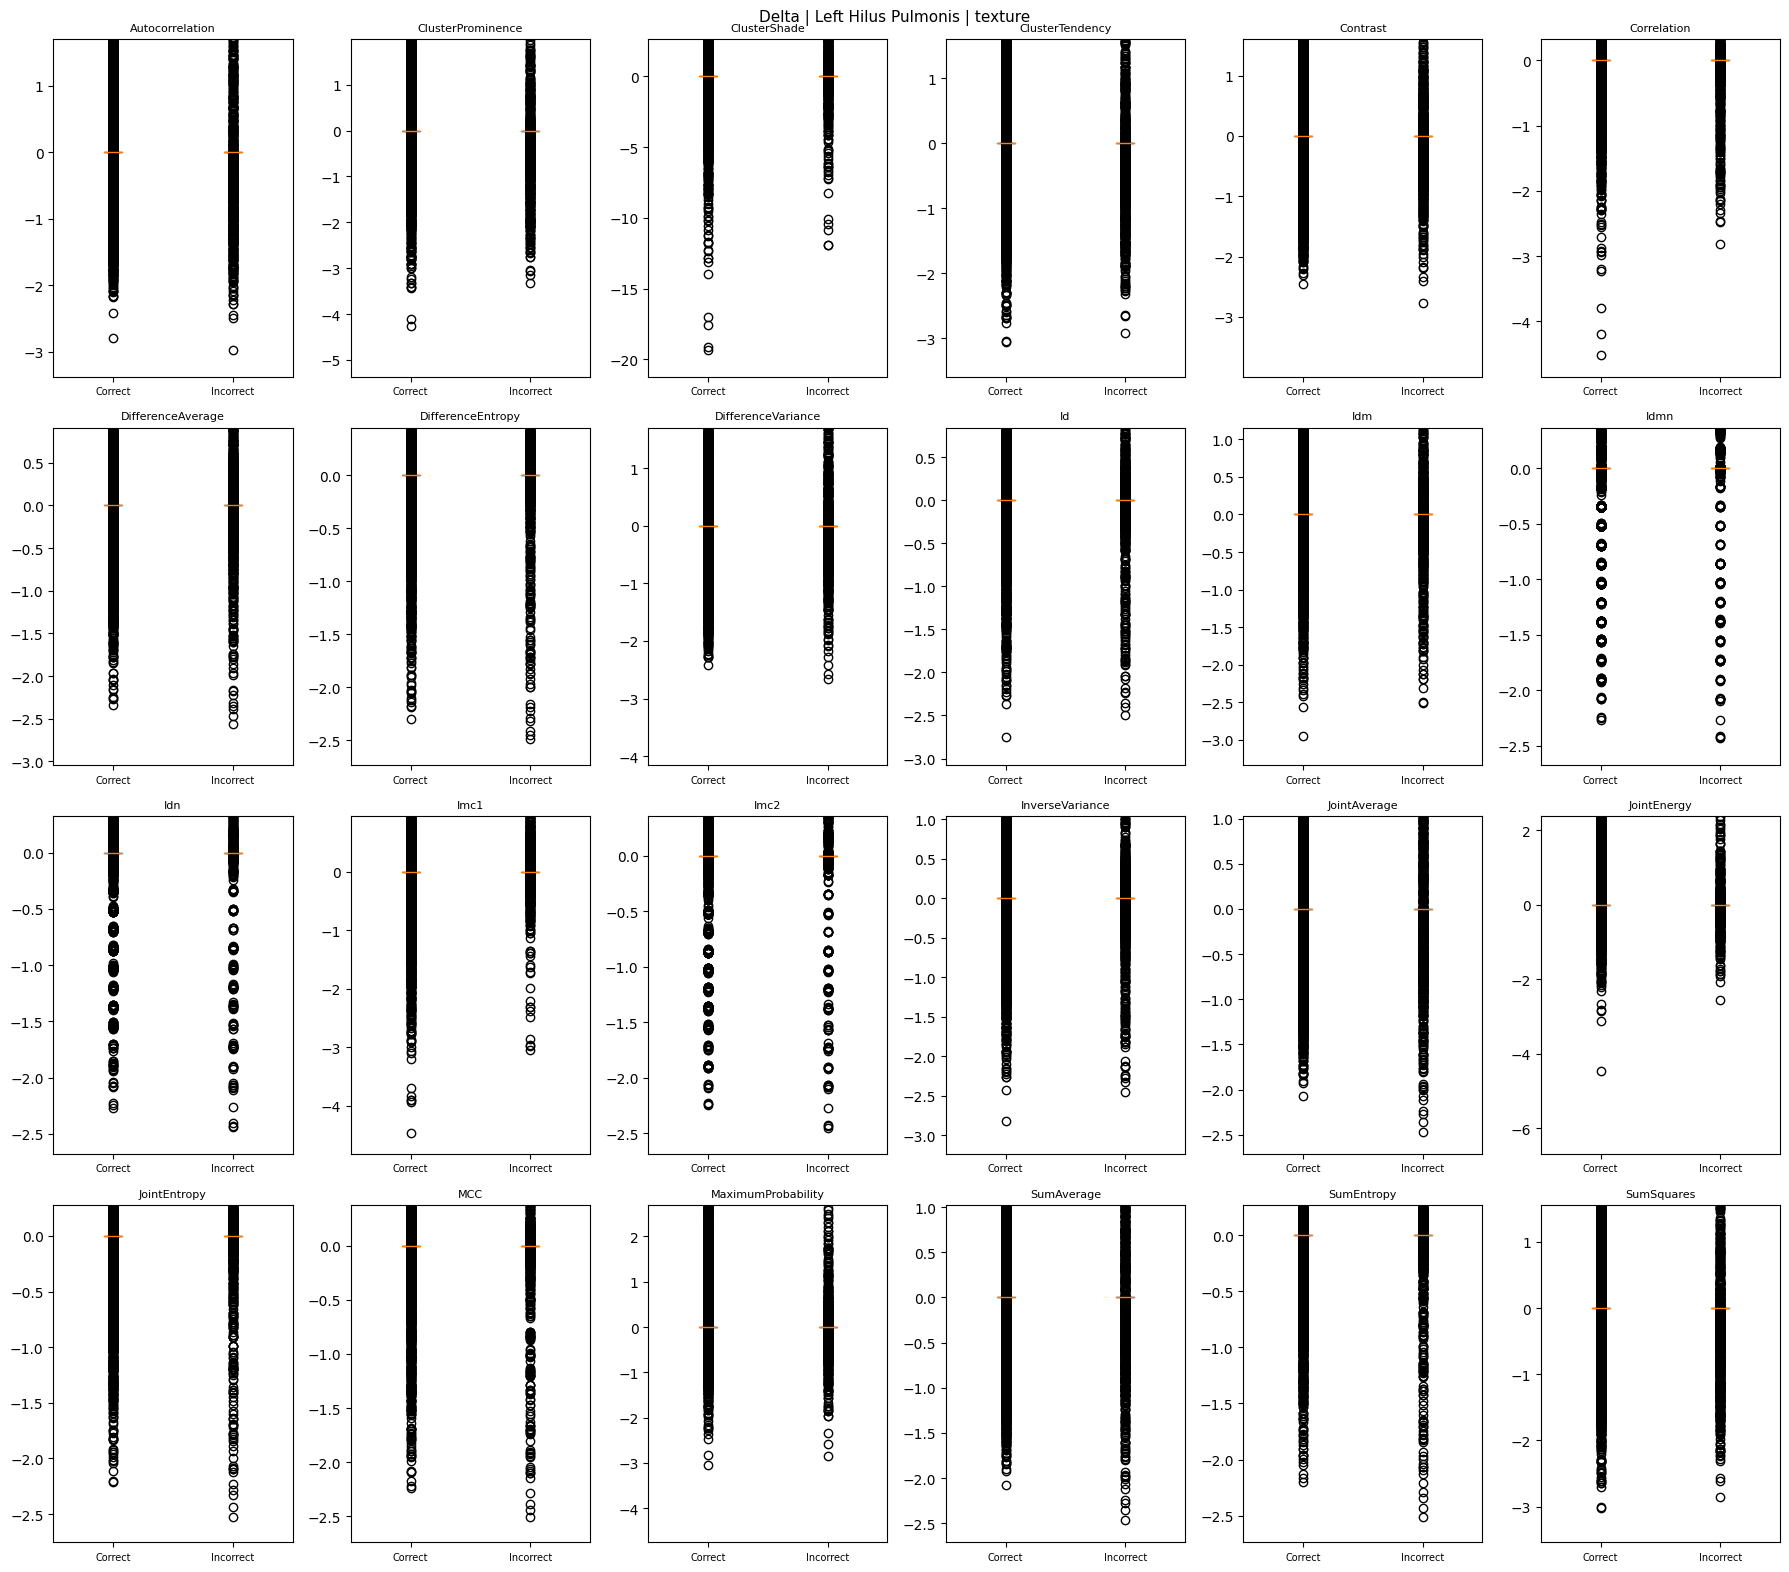

In [10]:
# Import necessary libraries for LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# Example: plot one 
example_category = "Delta | Left Hilus Pulmonis | texture"
plot_category(cf16_merged_data, example_category, categories[example_category])

In [16]:
delta_df

,delta_margin,delta_Aorta_area_pixels,delta_Aorta_bbox_height,delta_Aorta_bbox_ratio,delta_Aorta_bbox_width,delta_Aorta_original_firstorder_10Percentile,delta_Aorta_original_firstorder_90Percentile,delta_Aorta_original_firstorder_Energy,delta_Aorta_original_firstorder_Entropy,delta_Aorta_original_firstorder_InterquartileRange,...,delta_sex_female,delta_sex_male,delta_cardiothoracic_ratio,delta_lung_area_ratio,delta_lung_height_ratio,delta_lung_width_ratio,delta_left_lung_fraction,delta_right_lung_fraction,delta_mediastinal_ratio,correct
0,-0.230586,0.161948,-0.329628,4.106708e-06,0.513764,-0.170335,-0.340005,-0.413948,-0.111928,-0.396267,...,-0.554253,0.554253,-0.107141,0.000913,0.104545,-0.046285,0.125987,-0.124829,-0.338426,1
1,-1.518305,-0.139839,-0.369915,-4.588668e-06,-0.365112,-0.316563,-0.673463,-0.092851,-0.865030,-0.417903,...,-1.452604,1.452604,-0.019941,0.008367,0.585255,0.302790,1.165341,-1.154632,-0.246539,1
2,1.943578,0.622792,0.571354,-1.637290e-06,0.307737,-0.811875,0.514933,0.562877,0.315998,0.917380,...,1.684569,-1.684569,-0.400658,-0.000890,0.088649,-0.013268,-0.070204,0.069559,-0.171799,1
3,1.027058,0.035438,0.119032,-1.049264e-06,-0.065199,-0.175307,0.082910,-0.113068,0.194156,0.282827,...,0.980516,-0.980516,-0.628285,-0.000113,0.000101,0.001666,0.018513,-0.018343,-0.567288,1
4,1.610298,0.297741,0.382734,-6.714811e-07,0.106926,-0.035523,0.164208,0.546866,0.076699,0.305541,...,1.813892,-1.813892,-0.952276,-0.003323,-0.055702,-0.036498,-0.419503,0.415648,-0.634825,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45150,0.271777,-0.034556,-0.036676,-6.716104e-10,0.083634,0.360227,-0.128869,-0.090974,-0.160560,-0.551851,...,0.388373,-0.388373,0.063082,-0.006775,-0.312251,-0.039894,-1.054882,1.045853,1.865376,1
45151,0.247700,-0.108146,-0.168711,2.144020e-06,0.086248,0.406643,-0.103539,-0.158820,-0.080498,-0.331490,...,0.000018,-0.000018,0.626710,-0.007324,-0.233830,-0.046261,-1.133810,1.124105,0.961597,1
45152,0.456879,-0.434571,-0.234728,-1.563914e-06,-0.439078,0.317254,-0.124992,-0.105396,-0.227369,-0.605722,...,0.008632,-0.008632,0.201209,-0.005757,0.021892,-0.104896,-0.781651,0.774960,0.045281,1
45153,0.236409,0.054416,0.060516,-1.575321e-06,-0.117610,0.029433,-0.059080,-0.050228,-0.000720,-0.374267,...,0.000113,-0.000113,-0.086278,-0.005379,-0.290485,-0.077902,-0.721091,0.714919,0.896437,1


In [17]:
# Apply LDA to the delta features
X = delta_df.drop(columns=['correct']).values
y = delta_df['correct'].values
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)

In [18]:
# Print explained variance ratio
print("Explained variance ratio:", lda.explained_variance_ratio_)

Explained variance ratio: [1.]


In [19]:
# Print the most important features (those with the highest absolute coefficients in the LDA projection)
feature_importance = np.abs(lda.coef_[0])
feature_names = delta_df.drop(columns=['correct']).columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(20)

,feature,importance
550,delta_Right Hilus Pulmonis_original_glcm_SumSq...,363.965751
530,delta_Right Hilus Pulmonis_original_glcm_Clust...,351.334185
662,delta_Right Scapula_original_glcm_SumSquares,246.382566
642,delta_Right Scapula_original_glcm_ClusterTendency,236.423113
166,delta_Heart_original_shape2D_PixelSurface,202.656476
162,delta_Heart_original_shape2D_MeshSurface,194.735580
666,delta_Right Scapula_original_shape2D_MeshSurface,181.057465
670,delta_Right Scapula_original_shape2D_PixelSurface,180.842160
240,delta_Left Hilus Pulmonis_original_firstorder_...,162.352549
722,delta_Spine_original_shape2D_MeshSurface,158.241044


In [20]:
# Add a column for category
feature_importance_df['category'] = feature_importance_df['feature'].apply(
    lambda f: next((cat for cat, cols in categories.items() if f in cols), 'other'))

In [21]:
feature_importance_df.head(20)

,feature,importance,category
550,delta_Right Hilus Pulmonis_original_glcm_SumSq...,363.965751,Delta | Right Hilus Pulmonis | texture
530,delta_Right Hilus Pulmonis_original_glcm_Clust...,351.334185,Delta | Right Hilus Pulmonis | texture
662,delta_Right Scapula_original_glcm_SumSquares,246.382566,Delta | Right Scapula | texture
642,delta_Right Scapula_original_glcm_ClusterTendency,236.423113,Delta | Right Scapula | texture
166,delta_Heart_original_shape2D_PixelSurface,202.656476,Delta | Heart | shape2D
162,delta_Heart_original_shape2D_MeshSurface,194.735580,Delta | Heart | shape2D
666,delta_Right Scapula_original_shape2D_MeshSurface,181.057465,Delta | Right Scapula | shape2D
670,delta_Right Scapula_original_shape2D_PixelSurface,180.842160,Delta | Right Scapula | shape2D
240,delta_Left Hilus Pulmonis_original_firstorder_...,162.352549,Delta | Left Hilus Pulmonis | firstorder
722,delta_Spine_original_shape2D_MeshSurface,158.241044,Delta | Spine | shape2D


In [22]:
feature_importance_df

,feature,importance,category
550,delta_Right Hilus Pulmonis_original_glcm_SumSq...,363.965751,Delta | Right Hilus Pulmonis | texture
530,delta_Right Hilus Pulmonis_original_glcm_Clust...,351.334185,Delta | Right Hilus Pulmonis | texture
662,delta_Right Scapula_original_glcm_SumSquares,246.382566,Delta | Right Scapula | texture
642,delta_Right Scapula_original_glcm_ClusterTendency,236.423113,Delta | Right Scapula | texture
166,delta_Heart_original_shape2D_PixelSurface,202.656476,Delta | Heart | shape2D
...,...,...,...
691,delta_Spine_original_firstorder_Skewness,0.001867,Delta | Spine | firstorder
647,delta_Right Scapula_original_glcm_DifferenceVa...,0.000727,Delta | Right Scapula | texture
112,delta_Facies Diaphragmatica_perimeter,0.000460,Delta | Facies Diaphragmatica | geometric
522,delta_Right Hilus Pulmonis_original_firstorder...,0.000287,Delta | Right Hilus Pulmonis | firstorder


In [23]:
#. print the importances of the delta features grouped by category
category_importance = feature_importance_df.groupby('category')['importance'].sum().sort_values(ascending=False)
print(category_importance)  

category
Delta | Right Hilus Pulmonis | texture        778.601198
Delta | Right Scapula | texture               528.709265
Delta | Heart | shape2D                       398.471972
Delta | Left Hilus Pulmonis | firstorder      363.034183
Delta | Right Scapula | shape2D               362.270338
Delta | Aorta | texture                       351.422301
Delta | Mediastinum | texture                 341.145510
Delta | Facies Diaphragmatica | texture       329.578152
Delta | Spine | texture                       315.606472
Delta | Spine | shape2D                       315.244713
Delta | Left Hilus Pulmonis | shape2D         277.407677
Delta | Facies Diaphragmatica | shape2D       269.501453
Delta | Left Scapula | shape2D                267.461502
Delta | Right Lung | texture                  233.107649
Delta | Right Hilus Pulmonis | firstorder     195.064411
Delta | Mediastinum | shape2D                 190.147688
Delta | Left Scapula | texture                187.827073
Delta | Left Hilus Pul

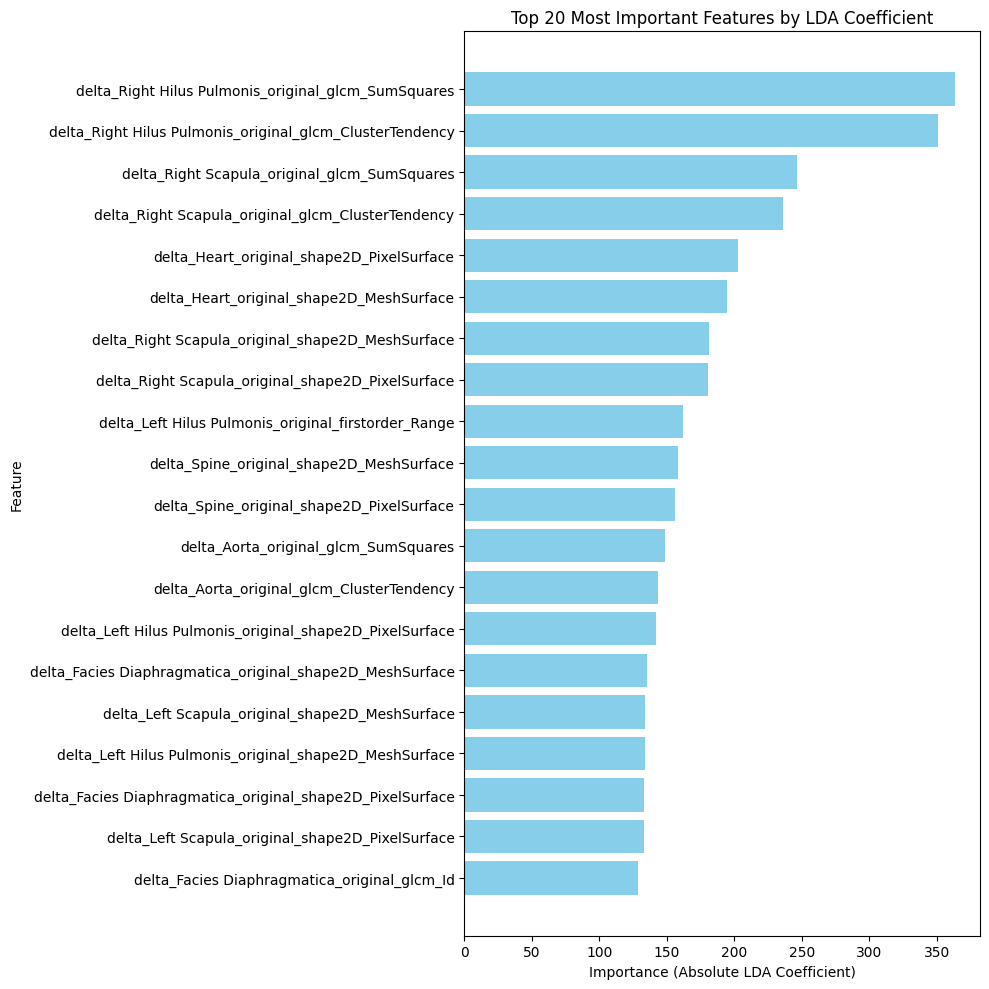

In [24]:
top_features = (
    feature_importance_df
    .sort_values('importance', ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 10))

plt.barh(
    top_features['feature'][::-1],
    top_features['importance'][::-1],
    color='skyblue'
)

plt.title('Top 20 Most Important Features by LDA Coefficient')
plt.xlabel('Importance (Absolute LDA Coefficient)')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()


Feature: delta_Right Hilus Pulmonis_original_glcm_SumSquares


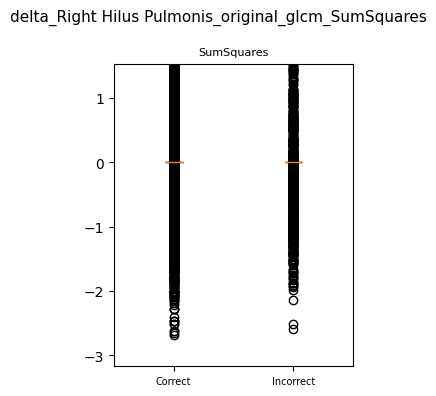


Feature: delta_Right Hilus Pulmonis_original_glcm_ClusterTendency


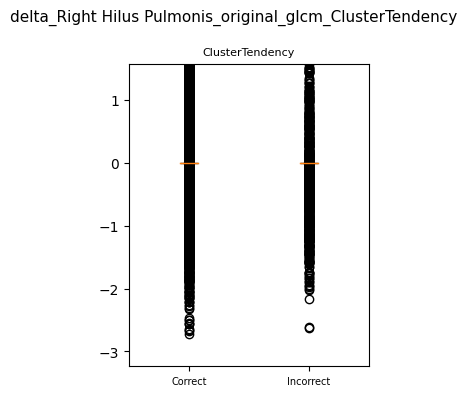


Feature: delta_Right Scapula_original_glcm_SumSquares


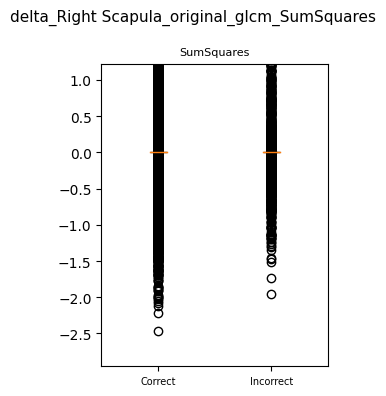


Feature: delta_Right Scapula_original_glcm_ClusterTendency


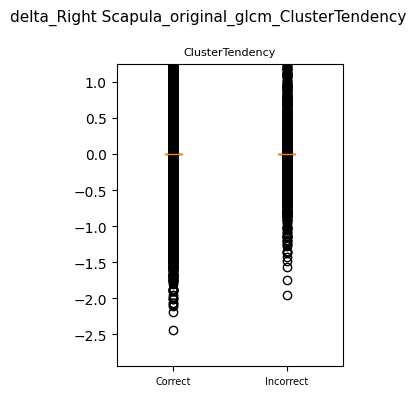


Feature: delta_Heart_original_shape2D_PixelSurface


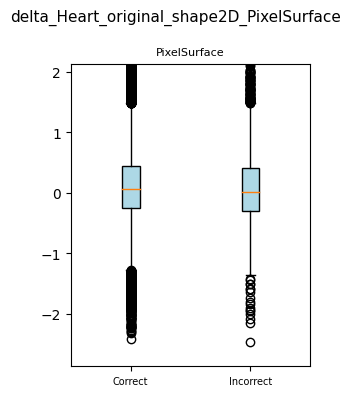


Feature: delta_Heart_original_shape2D_MeshSurface


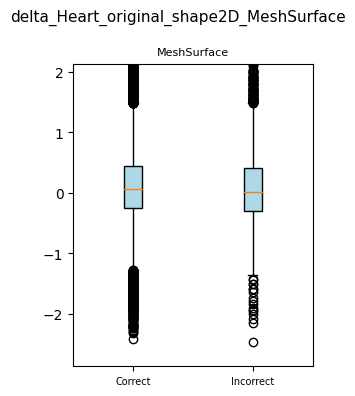


Feature: delta_Right Scapula_original_shape2D_MeshSurface


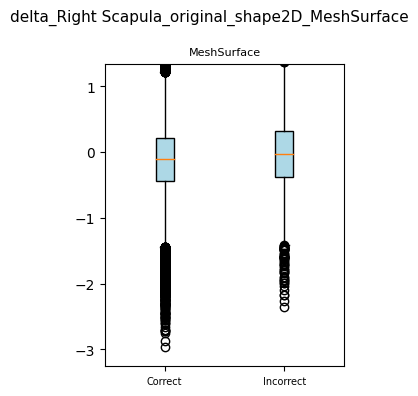


Feature: delta_Right Scapula_original_shape2D_PixelSurface


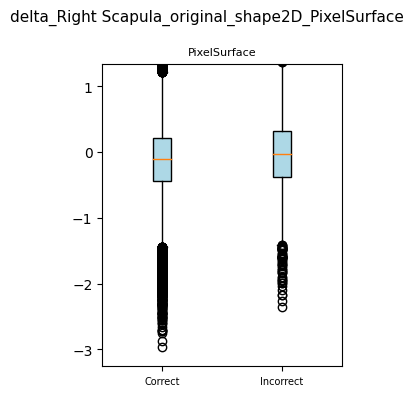


Feature: delta_Left Hilus Pulmonis_original_firstorder_Range


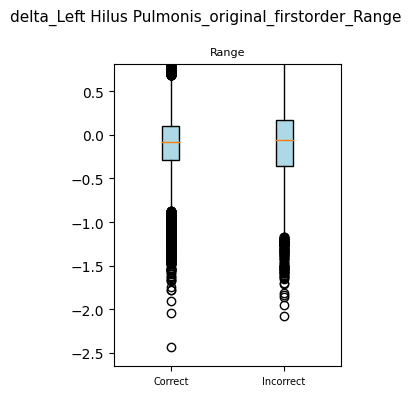


Feature: delta_Spine_original_shape2D_MeshSurface


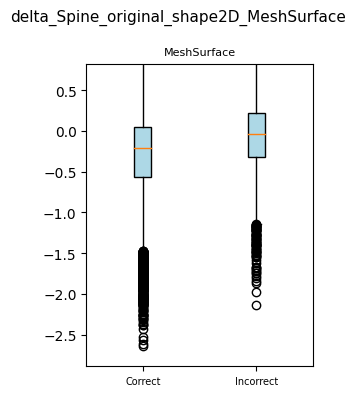


Feature: delta_Spine_original_shape2D_PixelSurface


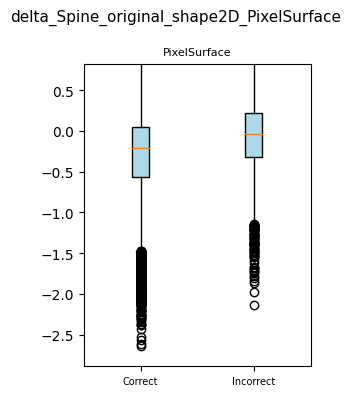


Feature: delta_Aorta_original_glcm_SumSquares


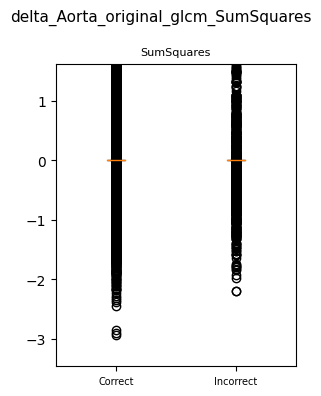


Feature: delta_Aorta_original_glcm_ClusterTendency


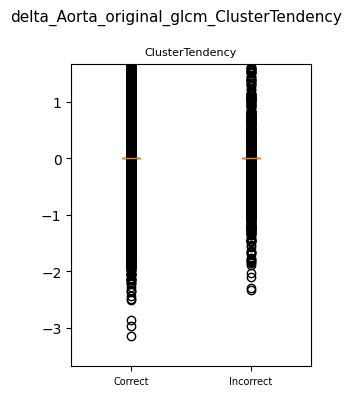


Feature: delta_Left Hilus Pulmonis_original_shape2D_PixelSurface


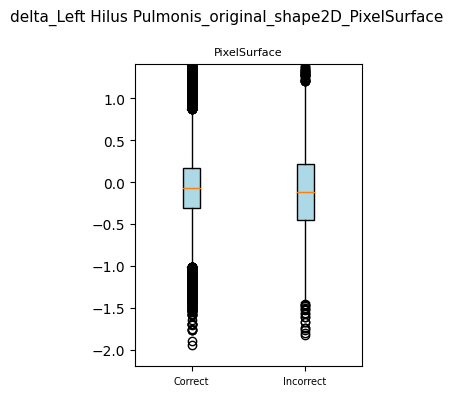


Feature: delta_Facies Diaphragmatica_original_shape2D_MeshSurface


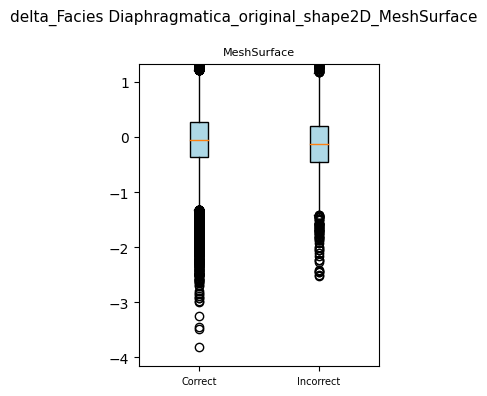


Feature: delta_Left Scapula_original_shape2D_MeshSurface


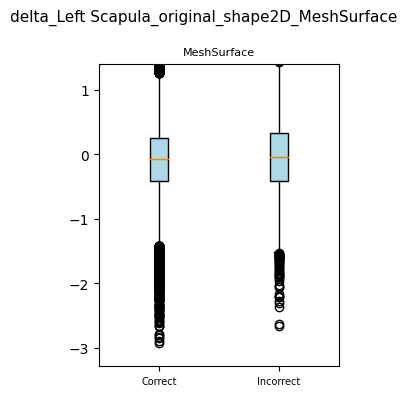


Feature: delta_Left Hilus Pulmonis_original_shape2D_MeshSurface


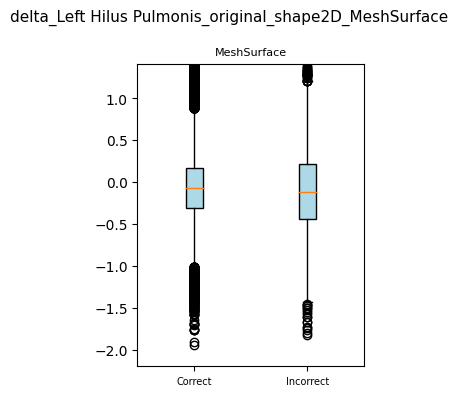


Feature: delta_Facies Diaphragmatica_original_shape2D_PixelSurface


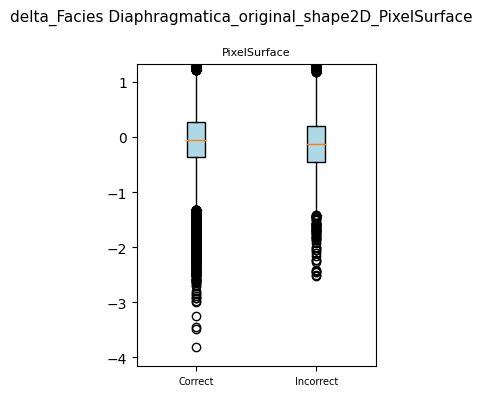


Feature: delta_Left Scapula_original_shape2D_PixelSurface


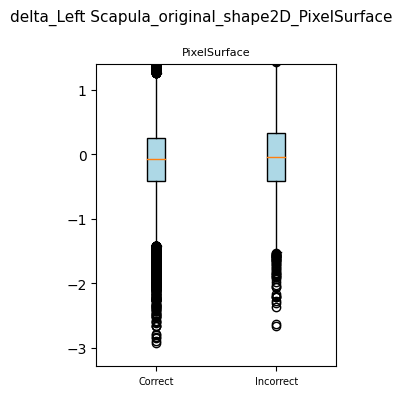


Feature: delta_Facies Diaphragmatica_original_glcm_Id


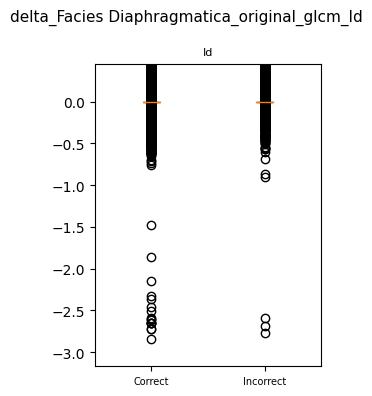

In [25]:
# Plot the top features (not grouped by category)
for feature in top_features['feature']:
    print(f"\nFeature: {feature}")
    plot_category(cf16_merged_data, feature, [feature])

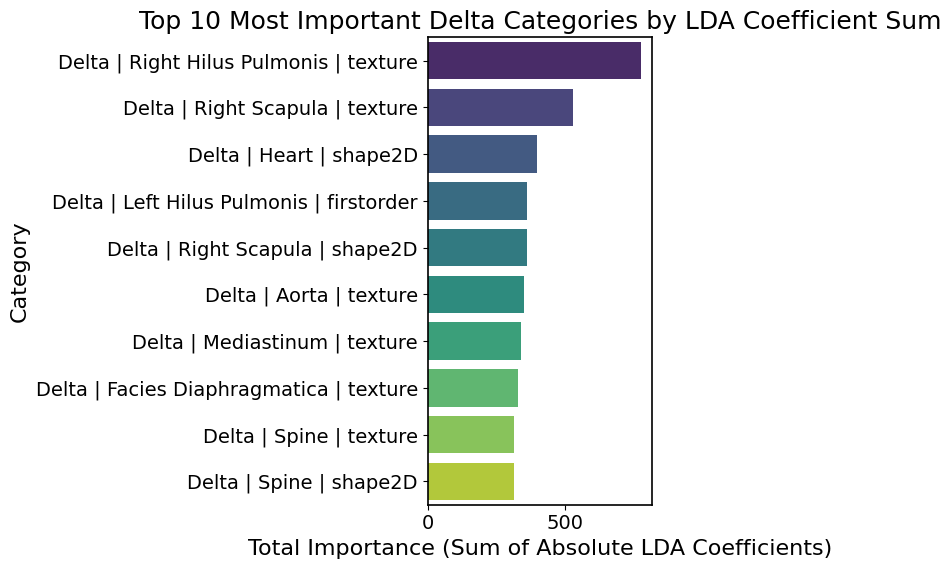

In [26]:
plt.rcParams.update({
    'font.size': 17,
    'axes.linewidth': 1.2,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
})

top_categories = (
    feature_importance_df
    .groupby('category', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
    .head(10)
)

# Now plot top categories
plt.figure(figsize=(7, 6))
sns.barplot(
    data=top_categories,
    x='importance',
    y='category',
    palette='viridis'
)
plt.title('Top 10 Most Important Delta Categories by LDA Coefficient Sum')
plt.xlabel('Total Importance (Sum of Absolute LDA Coefficients)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

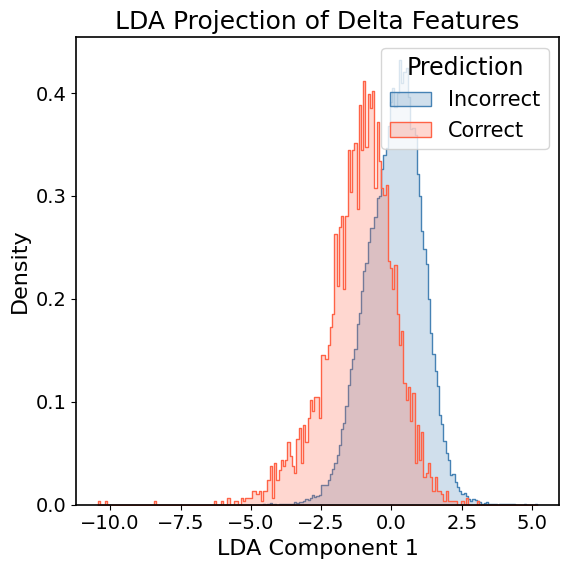

In [27]:
#LDA projection itself — not the coefficients, but the actual histogram of correct vs incorrect projected onto the single LDA axis.
plt.figure(figsize=(6, 6))
sns.histplot(
    x=X_lda[:, 0],
    hue=y,
    element='step',
    stat='density',
    common_norm=False,
    palette=['tomato', 'steelblue']
)
plt.title('LDA Projection of Delta Features')
plt.xlabel('LDA Component 1')
# legend (0 = incorrect and 1 = correct)
plt.legend(title='Prediction', labels=['Incorrect', 'Correct'])
plt.ylabel('Density')
plt.tight_layout()
plt.show()

In [28]:
from scipy import stats

# Get the LDA projections for each class
lda_correct   = X_lda[y == 1, 0]
lda_incorrect = X_lda[y == 0, 0]

# Pooled standard deviation
n1, n0 = len(lda_correct), len(lda_incorrect)
pooled_std = np.sqrt(
    ((n1 - 1) * lda_correct.std()**2 + (n0 - 1) * lda_incorrect.std()**2) 
    / (n1 + n0 - 2)
)

# Cohen's d
cohens_d = (lda_correct.mean() - lda_incorrect.mean()) / pooled_std

print(f"Mean correct:   {lda_correct.mean():.4f}")
print(f"Mean incorrect: {lda_incorrect.mean():.4f}")
print(f"Pooled std:     {pooled_std:.4f}")
print(f"Cohen's d:      {cohens_d:.4f}")

Mean correct:   0.1013
Mean incorrect: -1.1228
Pooled std:     1.0000
Cohen's d:      1.2242


### Mann-Whitney U test
is a nonparametric statistical test of the null hypothesis that randomly selected values X and Y from two populations have the same distribution.

The value of U calculated by the test can be converted to a measure of effect size by dividing it by the maximum value of U, which is the product of the sizes of the two samples being compared. This measure is the probability that the value of a random observation from the higher group will be greater than that of a random observation from the lower group.[1]

In [29]:
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

df = cf16_merged_data.copy()
delta_cols = [c for c in df.columns if c.startswith('delta_')]

results = []
for col in delta_cols:
    correct   = df.loc[df['correct'] == 1, col].dropna()
    incorrect = df.loc[df['correct'] == 0, col].dropna()
    
    stat, p = mannwhitneyu(correct, incorrect, alternative='two-sided')
    
    # Effect size: rank-biserial correlation (standard for Mann-Whitney)
    n1, n2 = len(correct), len(incorrect)
    r = 1 - (2 * stat) / (n1 * n2)
    
    results.append({'feature': col, 'p_value': p, 'effect_size_r': r})

results_df = pd.DataFrame(results)

# Bonferroni correction for multiple comparisons
results_df['p_corrected'] = results_df['p_value'] * len(delta_cols)
results_df['significant'] = results_df['p_corrected'] < 0.05

results_df = results_df.sort_values('effect_size_r', key=abs, ascending=False)
print(results_df.head(20).to_string(index=False))
print(f"\nSignificant features after Bonferroni: {results_df['significant'].sum()} / {len(delta_cols)}")

                                              feature       p_value  effect_size_r   p_corrected  significant
                 delta_Heart_original_firstorder_Mean 2.008195e-306      -0.368994 1.602540e-303         True
         delta_Heart_original_firstorder_10Percentile 3.630381e-299      -0.364566 2.897044e-296         True
              delta_Heart_original_firstorder_Minimum 7.523676e-294      -0.361289 6.003894e-291         True
      delta_Heart_original_firstorder_RootMeanSquared 4.044999e-275      -0.349496 3.227909e-272         True
               delta_Heart_original_firstorder_Median 6.396609e-234      -0.322044 5.104494e-231         True
                delta_Heart_original_firstorder_Range 5.275452e-216       0.309349 4.209811e-213         True
        delta_Right Lung_original_firstorder_Skewness 1.345396e-184       0.285739 1.073626e-181         True
          delta_Heart_original_firstorder_TotalEnergy 1.761234e-183      -0.284864 1.405465e-180         True
          

In [30]:
results_df

,feature,p_value,effect_size_r,p_corrected,significant
124,delta_Heart_original_firstorder_Mean,2.008195e-306,-0.368994,1.602540e-303,True
117,delta_Heart_original_firstorder_10Percentile,3.630381e-299,-0.364566,2.897044e-296,True
127,delta_Heart_original_firstorder_Minimum,7.523676e-294,-0.361289,6.003894e-291,True
130,delta_Heart_original_firstorder_RootMeanSquared,4.044999e-275,-0.349496,3.227909e-272,True
126,delta_Heart_original_firstorder_Median,6.396609e-234,-0.322044,5.104494e-231,True
...,...,...,...,...,...
64,delta_Facies Diaphragmatica_original_firstorde...,9.636324e-01,-0.000450,7.689787e+02,False
366,delta_Left Scapula_original_glcm_DifferenceEnt...,9.594210e-01,-0.000346,7.656179e+02,False
494,delta_Right Clavicle_original_glcm_SumSquares,9.673058e-01,0.000278,7.719100e+02,False
431,delta_Mediastinum_original_glcm_JointAverage,9.909315e-01,-0.000077,7.907633e+02,False


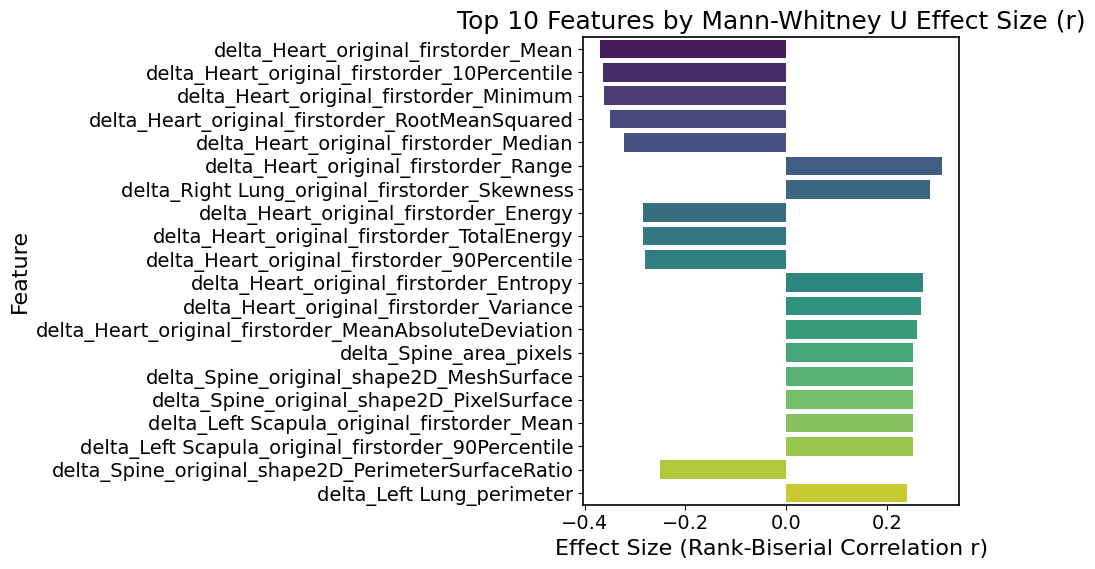

In [31]:
# Plot the top 10 features by effect size
top_mwu = results_df.sort_values('effect_size_r', key=abs, ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_mwu,
    x='effect_size_r',
    y='feature',
    palette='viridis',
    orient='h'
)
plt.title('Top 10 Features by Mann-Whitney U Effect Size (r)')
plt.xlabel('Effect Size (Rank-Biserial Correlation r)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [32]:
df = cf16_merged_data.copy()

# Create TP/TN/FP/FN column
def get_quadrant(row):
    p, t = int(row[f'effusion_pred']), int(row[f'effusion_true'])
    if p == 1 and t == 1: return 'TP'
    if p == 0 and t == 0: return 'TN'
    if p == 1 and t == 0: return 'FP'
    if p == 0 and t == 1: return 'FN'

df['quadrant'] = df.apply(get_quadrant, axis=1)
print(df['quadrant'].value_counts())

quadrant
TP    32053
TN     9365
FN     2469
FP     1268
Name: count, dtype: int64


In [33]:
results = []
for col in delta_cols:
    tp = df.loc[df['quadrant'] == 'TP', col].dropna()
    fp = df.loc[df['quadrant'] == 'FP', col].dropna()
    tn = df.loc[df['quadrant'] == 'TN', col].dropna()
    fn = df.loc[df['quadrant'] == 'FN', col].dropna()
    
    stat1, p1 = mannwhitneyu(tp, fp, alternative='two-sided')
    r1 = 1 - (2 * stat1) / (len(tp) * len(fp))
    
    stat2, p2 = mannwhitneyu(tn, fn, alternative='two-sided')
    r2 = 1 - (2 * stat2) / (len(tn) * len(fn))
    
    results.append({
        'feature': col,
        'r_TP_vs_FP': r1,
        'p_TP_vs_FP': p1,
        'r_TN_vs_FN': r2,
        'p_TN_vs_FN': p2,
    })

results_df = pd.DataFrame(results)

# Bonferroni correction
n_tests = len(delta_cols) * 2  # two comparisons per feature
results_df['p_TP_vs_FP_corrected'] = results_df['p_TP_vs_FP'] * n_tests
results_df['p_TN_vs_FN_corrected'] = results_df['p_TN_vs_FN'] * n_tests

# Sort by average absolute effect size across both comparisons
results_df['mean_abs_r'] = (results_df['r_TP_vs_FP'].abs() + results_df['r_TN_vs_FN'].abs()) / 2
results_df = results_df.sort_values('mean_abs_r', ascending=False)

print(results_df[['feature', 'r_TP_vs_FP', 'r_TN_vs_FN', 
                   'p_TP_vs_FP_corrected', 'p_TN_vs_FN_corrected']].head(20).to_string(index=False))

                                                    feature  r_TP_vs_FP  r_TN_vs_FN  p_TP_vs_FP_corrected  p_TN_vs_FN_corrected
                   delta_Heart_original_firstorder_Variance    0.316511   -0.262824          1.669240e-78          7.667048e-87
      delta_Heart_original_firstorder_MeanAbsoluteDeviation    0.310656   -0.262077          1.406205e-75          2.424374e-86
delta_Heart_original_firstorder_RobustMeanAbsoluteDeviation    0.293413   -0.271210          2.810272e-67          1.483638e-92
         delta_Heart_original_firstorder_InterquartileRange    0.285050   -0.279279          2.019876e-63          3.201934e-98
               delta_Heart_original_firstorder_10Percentile   -0.325577    0.236357          3.844440e-83          5.567151e-70
                    delta_Heart_original_firstorder_Entropy    0.282668   -0.263095          2.417068e-62          5.044865e-87
                 delta_Heart_original_firstorder_Uniformity   -0.241659    0.232951          3.435543e-4

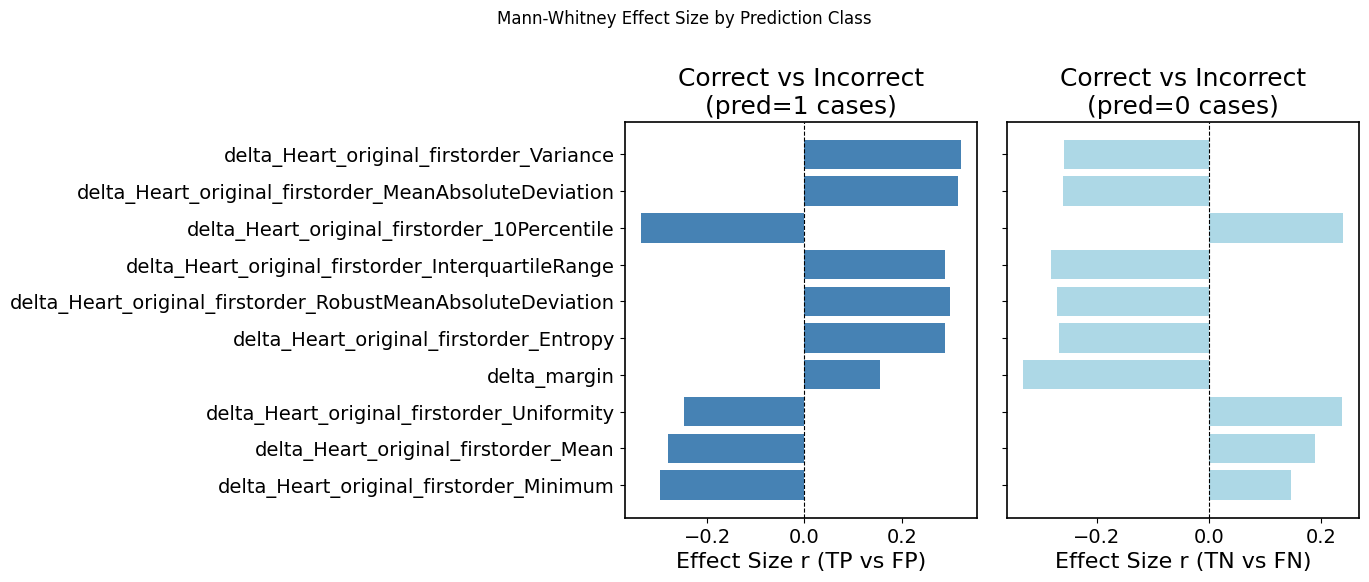

In [45]:
top_features = results_df.head(10)['feature'].tolist()
top_df = results_df[results_df['feature'].isin(top_features)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# TP vs FP
axes[0].barh(top_df['feature'], top_df['r_TP_vs_FP'], color='steelblue')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Effect Size r (TP vs FP)')
axes[0].set_title('Correct vs Incorrect\n(pred=1 cases)')
axes[0].invert_yaxis()

# TN vs FN
axes[1].barh(top_df['feature'], top_df['r_TN_vs_FN'], color='lightblue')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Effect Size r (TN vs FN)')
axes[1].set_title('Correct vs Incorrect\n(pred=0 cases)')

plt.suptitle('Mann-Whitney Effect Size by Prediction Class', fontsize=12)
plt.tight_layout()
plt.show()

In [2]:
quadrants = ['TP', 'TN', 'FP', 'FN']
mw_df = results_df.copy()  # after running the Mann-Whitney loop

# Then run the quadrant means loop - this creates a new results_df
results = []
for col in delta_cols:
    row = {'feature': col}
    for q in quadrants:
        row[f'mean_{q}'] = df.loc[df['quadrant'] == q, col].mean()
        row[f'std_{q}']  = df.loc[df['quadrant'] == q, col].std()
        row[f'count_{q}'] = df.loc[df['quadrant'] == q, col].count()
    results.append(row)
means_df = pd.DataFrame(results)

# Now use mw_df to get top features, and means_df to get the values for plotting
top_features = mw_df.head(5)['feature'].tolist()


# Rest of your plotting code, but referencing means_df instead of results_df
fig, axes = plt.subplots(1, len(top_features), figsize=(16, 5))
for ax, feat in zip(axes, top_features):
    means = [means_df.loc[means_df['feature'] == feat, f'mean_{q}'].values[0] 
             for q in quadrants]
    sems  = [means_df.loc[means_df['feature'] == feat, f'std_{q}'].values[0] / 
             np.sqrt(means_df.loc[means_df['feature'] == feat, f'count_{q}'].values[0]) 
             for q in quadrants]
    colors = ['steelblue', 'lightblue', 'tomato', 'lightsalmon']
    ax.bar(quadrants, means, color=colors, yerr=sems,
           capsize=5, error_kw={'linewidth': 1.5, 'color': 'black'})
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(feat.replace('delta_', 'Delta ').replace('_original_firstorder_', ' Firstorder\n'),
                 fontsize=9)
    ax.set_ylabel('Mean delta value')

plt.suptitle('Mean delta by prediction quadrant (TP/TN/FP/FN)', fontsize=12)
plt.tight_layout()
plt.show()

NameError: name 'results_df' is not defined

### Different in dirrectionality

In [47]:
# Define clinical relevance groups
clinical_keywords = ['Heart', 'Lung',]

# Select delta columns
clinical_cols     = [c for c in delta_cols if any(k in c for k in clinical_keywords)]
nonclinical_cols  = [c for c in delta_cols if c not in clinical_cols]

print(f"Clinical features:     {len(clinical_cols)}")
print(f"Non-clinical features: {len(nonclinical_cols)}")

# For each sample compute the L2 norm of clinical vs non-clinical delta
# Essentially, the norm of the delta vector but calculated separately for the clinical and non-clinical spaces

# First for clinical and non-clinical separately, then for the total delta vector as well
df['norm_clinical']    = np.linalg.norm(df[clinical_cols].values, axis=1)
df['norm_nonclinical'] = np.linalg.norm(df[nonclinical_cols].values, axis=1)

df['norm_total']       = np.linalg.norm(df[delta_cols].values, axis=1)

# Fraction of total delta that is clinical
df['clinical_fraction'] = df['norm_clinical'] / (df['norm_total'] + 1e-8)

# Compare across quadrants
summary = df.groupby('quadrant')[['clinical_fraction', 
                                   'norm_clinical', 
                                   'norm_nonclinical']].mean()
print(summary)

Clinical features:     96
Non-clinical features: 366
          clinical_fraction  norm_clinical  norm_nonclinical
quadrant                                                    
FN                 0.436382       5.407272         11.105206
FP                 0.459147       6.161753         11.845026
TN                 0.426462       4.398668          9.298119
TP                 0.499634       6.912750         11.878701


In [48]:
df['mean_clinical']    = df[clinical_cols].abs().mean(axis=1)
df['mean_nonclinical'] = df[nonclinical_cols].abs().mean(axis=1)
df['clinical_fraction_norm'] = df['mean_clinical'] / (df['mean_clinical'] + df['mean_nonclinical'] + 1e-8)

summary = df.groupby('quadrant')[['clinical_fraction_norm', 
                                   'mean_clinical', 
                                   'mean_nonclinical']].mean()
print(summary)

          clinical_fraction_norm  mean_clinical  mean_nonclinical
quadrant                                                         
FN                      0.504424       0.418340          0.398162
FP                      0.520149       0.475081          0.421781
TN                      0.500423       0.336891          0.328058
TP                      0.550615       0.531790          0.415912


/tmp/ipykernel_3230605/1261467588.py:49: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(tick_labels)


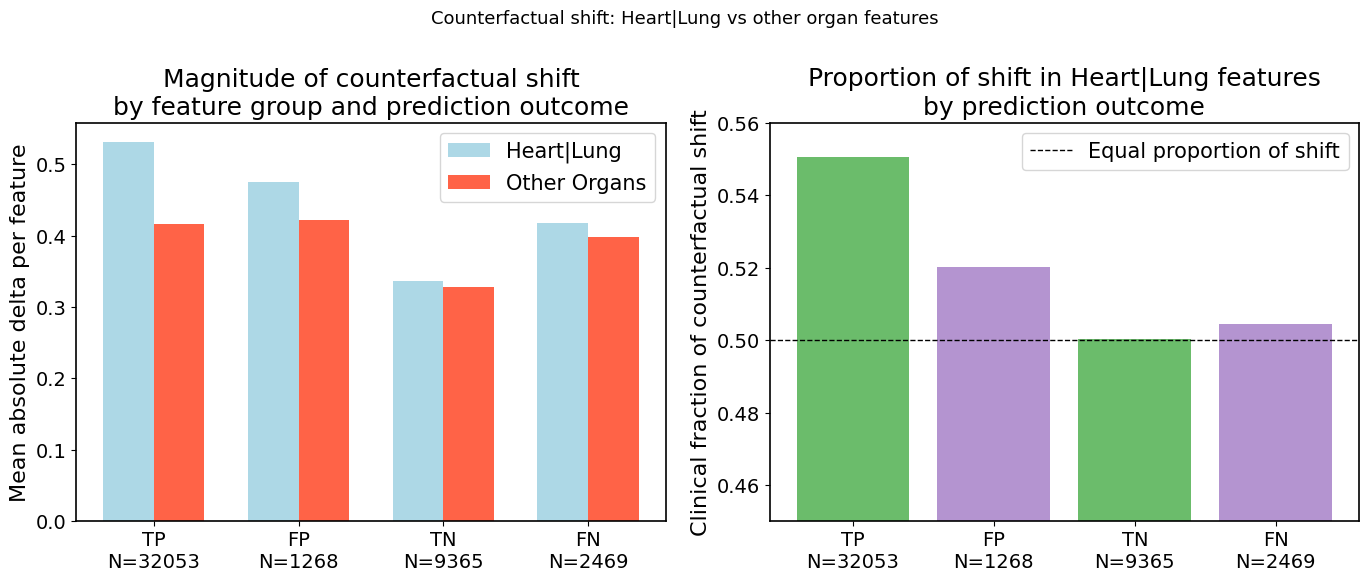

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

quadrants = ['TP', 'FP', 'TN', 'FN']  # ordered by prediction class
colors_clinical    = ['steelblue', 'tomato', 'lightblue', 'lightsalmon']
colors_nonclinical = ['#2c7bb6', '#d7191c', '#abd9e9', '#fdae61']

# ── Plot 1: Absolute magnitudes ───────────────────────────────────────────
x = np.arange(len(quadrants))
width = 0.35

clinical_means    = [df.loc[df['quadrant']==q, 'mean_clinical'].mean() for q in quadrants]
nonclinical_means = [df.loc[df['quadrant']==q, 'mean_nonclinical'].mean() for q in quadrants]

axes[0].bar(x - width/2, clinical_means, width, label='Heart|Lung', color='lightblue')
axes[0].bar(x + width/2, nonclinical_means, width, label='Other Organs', color='tomato')
# add N= to tick labels
tick_labels = []
for q in quadrants:
    count = df.loc[df['quadrant'] == q, 'clinical_fraction_norm'].count()
    tick_labels.append(f"{q}\nN={count}")   
axes[0].set_xticks(x)
axes[0].set_xticklabels(tick_labels)
axes[0].set_ylabel('Mean absolute delta per feature')
axes[0].set_title('Magnitude of counterfactual shift\nby feature group and prediction outcome')
axes[0].legend()
axes[0].axhline(0, color='black', linewidth=0.8)

# ── Plot 2: Clinical fraction ─────────────────────────────────────────────
clinical_fractions = [df.loc[df['quadrant']==q, 'clinical_fraction_norm'].mean() 
                      for q in quadrants]
# bar colors cannot be lightblue or salmon because they are used in the first plot, so we use different shades of blue and red
# purple
B4_COLOR = '#2ca02c'  # Matplotlib default green
M6_COLOR = '#9467bd'  # Matplotlib default purple

bar_colors = [B4_COLOR, M6_COLOR, B4_COLOR, M6_COLOR]

axes[1].bar(quadrants, clinical_fractions, color=bar_colors,alpha=0.7)
axes[1].axhline(0.5, color='black', linewidth=1, linestyle='--', 
                label='Equal proportion of shift')
axes[1].set_ylabel('Clinical fraction of counterfactual shift')
axes[1].set_title('Proportion of shift in Heart|Lung features\nby prediction outcome')
axes[1].set_ylim(0.45, 0.56)
# add N= to tick labels
tick_labels = []
for q in quadrants:
    count = df.loc[df['quadrant'] == q, 'clinical_fraction_norm'].count()
    tick_labels.append(f"{q}\nN={count}")
axes[1].set_xticklabels(tick_labels)
axes[1].legend()

plt.suptitle('Counterfactual shift: Heart|Lung vs other organ features', fontsize=13)
plt.tight_layout()
plt.show()

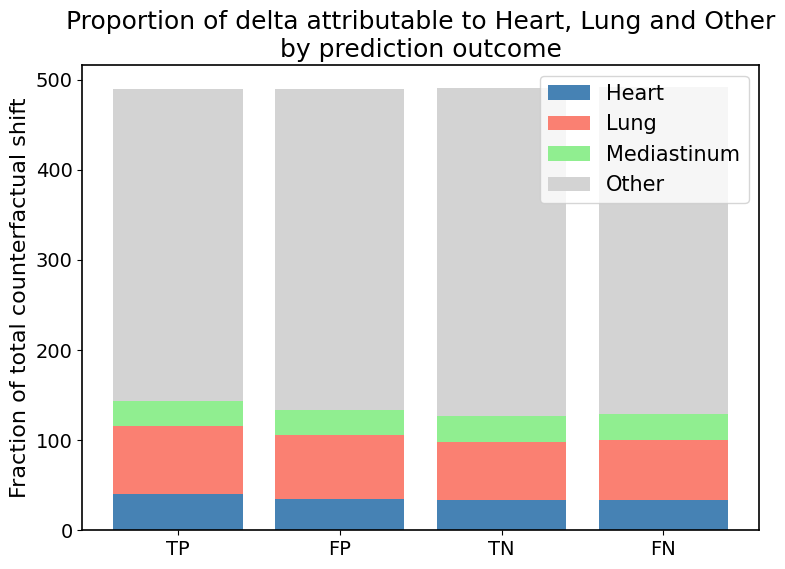

In [54]:
heart_cols = [c for c in delta_cols if 'Heart' in c]
lung_cols  = [c for c in delta_cols if 'Lung' in c]
mediastinum_cols = [c for c in delta_cols if 'Mediastinum' in c]   
other_cols = [c for c in delta_cols if c not in heart_cols and c not in lung_cols]

quadrants = ['TP', 'FP', 'TN', 'FN']

heart_fractions = []
lung_fractions  = []
mediastinum_fractions = []
other_fractions = []

for q in quadrants:
    subset = df[df['quadrant'] == q]
    
    total  = subset[delta_cols].abs().mean().mean()  # mean absolute delta per feature, averaged across all features
    heart  = subset[heart_cols].abs().mean().sum()
    lung   = subset[lung_cols].abs().mean().sum()
    mediastinum = subset[mediastinum_cols].abs().mean().sum()
    other  = subset[other_cols].abs().mean().sum()
    
    heart_fractions.append(heart / total)
    lung_fractions.append(lung / total)
    mediastinum_fractions.append(mediastinum / total)
    other_fractions.append(other / total)

x = np.arange(len(quadrants))

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x, heart_fractions, label='Heart', color='steelblue')
ax.bar(x, lung_fractions,  bottom=heart_fractions, label='Lung', color='salmon')
ax.bar(x, mediastinum_fractions, 
       bottom=[h+l for h,l in zip(heart_fractions, lung_fractions)], 
       label='Mediastinum', color='lightgreen')
ax.bar(x, other_fractions, 
       bottom=[h+l+m for h,l,m in zip(heart_fractions, lung_fractions, mediastinum_fractions)],     
       label='Other', color='lightgrey')

ax.set_xticks(x)
ax.set_xticklabels(quadrants)
ax.set_ylabel('Fraction of total counterfactual shift')
ax.set_title('Proportion of delta attributable to Heart, Lung and Other\nby prediction outcome')
ax.legend()
plt.tight_layout()
plt.show()

---

# New Approach - Correlation between attributes and correctness of predictions
- Calculate the correlation between each attribute and the correctness of predictions (binary variable: correct/incorrect)
- Get the absolute value of the correlation to see which attributes are most strongly associated with each outcome (TP, FP, TN, FN)

In [11]:
delta_df

,delta_margin,delta_Aorta_area_pixels,delta_Aorta_bbox_height,delta_Aorta_bbox_ratio,delta_Aorta_bbox_width,delta_Aorta_original_firstorder_10Percentile,delta_Aorta_original_firstorder_90Percentile,delta_Aorta_original_firstorder_Energy,delta_Aorta_original_firstorder_Entropy,delta_Aorta_original_firstorder_InterquartileRange,...,delta_sex_female,delta_sex_male,delta_cardiothoracic_ratio,delta_lung_area_ratio,delta_lung_height_ratio,delta_lung_width_ratio,delta_left_lung_fraction,delta_right_lung_fraction,delta_mediastinal_ratio,correct
0,-0.230586,0.161948,-0.329628,4.106708e-06,0.513764,-0.170335,-0.340005,-0.413948,-0.111928,-0.396267,...,-0.554253,0.554253,-0.107141,0.000913,0.104545,-0.046285,0.125987,-0.124829,-0.338426,1
1,-1.518305,-0.139839,-0.369915,-4.588668e-06,-0.365112,-0.316563,-0.673463,-0.092851,-0.865030,-0.417903,...,-1.452604,1.452604,-0.019941,0.008367,0.585255,0.302790,1.165341,-1.154632,-0.246539,1
2,1.943578,0.622792,0.571354,-1.637290e-06,0.307737,-0.811875,0.514933,0.562877,0.315998,0.917380,...,1.684569,-1.684569,-0.400658,-0.000890,0.088649,-0.013268,-0.070204,0.069559,-0.171799,1
3,1.027058,0.035438,0.119032,-1.049264e-06,-0.065199,-0.175307,0.082910,-0.113068,0.194156,0.282827,...,0.980516,-0.980516,-0.628285,-0.000113,0.000101,0.001666,0.018513,-0.018343,-0.567288,1
4,1.610298,0.297741,0.382734,-6.714811e-07,0.106926,-0.035523,0.164208,0.546866,0.076699,0.305541,...,1.813892,-1.813892,-0.952276,-0.003323,-0.055702,-0.036498,-0.419503,0.415648,-0.634825,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45150,0.271777,-0.034556,-0.036676,-6.716104e-10,0.083634,0.360227,-0.128869,-0.090974,-0.160560,-0.551851,...,0.388373,-0.388373,0.063082,-0.006775,-0.312251,-0.039894,-1.054882,1.045853,1.865376,1
45151,0.247700,-0.108146,-0.168711,2.144020e-06,0.086248,0.406643,-0.103539,-0.158820,-0.080498,-0.331490,...,0.000018,-0.000018,0.626710,-0.007324,-0.233830,-0.046261,-1.133810,1.124105,0.961597,1
45152,0.456879,-0.434571,-0.234728,-1.563914e-06,-0.439078,0.317254,-0.124992,-0.105396,-0.227369,-0.605722,...,0.008632,-0.008632,0.201209,-0.005757,0.021892,-0.104896,-0.781651,0.774960,0.045281,1
45153,0.236409,0.054416,0.060516,-1.575321e-06,-0.117610,0.029433,-0.059080,-0.050228,-0.000720,-0.374267,...,0.000113,-0.000113,-0.086278,-0.005379,-0.290485,-0.077902,-0.721091,0.714919,0.896437,1


In [12]:
# Create new dataframe, each row is a delta features, then the columns are correlation with correctness, correctness, and category
correlations = []
for col in delta_cols:
    correlation_to_correctness = delta_df[[col, 'correct']].corr().iloc[0, 1]  # correlation between feature and correctness
    correlations.append({'feature': col, 'correlation': correlation_to_correctness})
correlations_df = pd.DataFrame(correlations)
correlations_df['category'] = correlations_df['feature'].apply(
    lambda f: next((cat for cat, cols in categories.items() if f in cols), 'other'))
# remove "Delta | " from category names for better readability
correlations_df['category'] = correlations_df['category'].str.replace('Delta | ', '')
correlations_df

,feature,correlation,category
0,delta_margin,-0.034798,Global | other
1,delta_Aorta_area_pixels,0.005784,Aorta | geometric
2,delta_Aorta_bbox_height,-0.018500,Aorta | geometric
3,delta_Aorta_bbox_ratio,0.004403,Aorta | geometric
4,delta_Aorta_bbox_width,0.013671,Aorta | geometric
...,...,...,...
793,delta_lung_height_ratio,-0.006939,Global | other
794,delta_lung_width_ratio,0.001888,Global | other
795,delta_left_lung_fraction,-0.075687,Global | other
796,delta_right_lung_fraction,0.074170,Global | other


In [13]:
correlations_df

,feature,correlation,category
0,delta_margin,-0.034798,Global | other
1,delta_Aorta_area_pixels,0.005784,Aorta | geometric
2,delta_Aorta_bbox_height,-0.018500,Aorta | geometric
3,delta_Aorta_bbox_ratio,0.004403,Aorta | geometric
4,delta_Aorta_bbox_width,0.013671,Aorta | geometric
...,...,...,...
793,delta_lung_height_ratio,-0.006939,Global | other
794,delta_lung_width_ratio,0.001888,Global | other
795,delta_left_lung_fraction,-0.075687,Global | other
796,delta_right_lung_fraction,0.074170,Global | other


In [14]:
# Sort by strongest positive correlations
top_n = 20

# The top should be in absolute value, not just positive
top_features = correlations_df.sort_values('correlation', key=abs, ascending=False).head(top_n)


top_features['short_feature'] = (
    top_features['feature']
    .str.replace('delta_', ' ', regex=False)
    .str.replace('_original_', '', regex=False)
)

In [15]:
top_features

,feature,correlation,category,short_feature
127,delta_Heart_original_firstorder_Minimum,0.170349,Heart | firstorder,Heartfirstorder_Minimum
117,delta_Heart_original_firstorder_10Percentile,0.168241,Heart | firstorder,Heartfirstorder_10Percentile
124,delta_Heart_original_firstorder_Mean,0.164450,Heart | firstorder,Heartfirstorder_Mean
130,delta_Heart_original_firstorder_RootMeanSquared,0.156977,Heart | firstorder,Heartfirstorder_RootMeanSquared
128,delta_Heart_original_firstorder_Range,-0.145511,Heart | firstorder,Heartfirstorder_Range
126,delta_Heart_original_firstorder_Median,0.142225,Heart | firstorder,Heartfirstorder_Median
579,delta_Right Lung_original_firstorder_Skewness,-0.132802,Right Lung | firstorder,Right Lungfirstorder_Skewness
118,delta_Heart_original_firstorder_90Percentile,0.125792,Heart | firstorder,Heartfirstorder_90Percentile
119,delta_Heart_original_firstorder_Energy,0.125426,Heart | firstorder,Heartfirstorder_Energy
132,delta_Heart_original_firstorder_TotalEnergy,0.125426,Heart | firstorder,Heartfirstorder_TotalEnergy


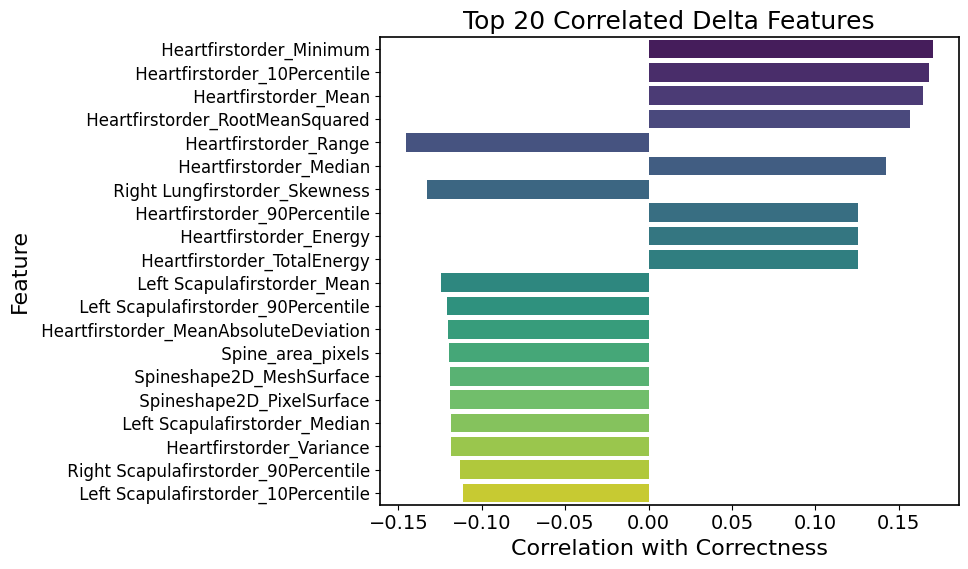

In [16]:


plt.rcParams.update({
    'font.size': 17,
    'axes.linewidth': 1.2,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 12,
    'legend.fontsize': 15,
})
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    y='short_feature',
    x='correlation',
    palette='viridis',
    dodge=False
)
# text for legend
plt.title(f'Top {top_n} Correlated Delta Features')
plt.xlabel('Correlation with Correctness')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Look at each quadrant

In [17]:
df = cf16_merged_data.copy()

# Create TP/TN/FP/FN column
def get_quadrant(row):
    p, t = int(row[f'effusion_pred']), int(row[f'effusion_true'])
    if p == 1 and t == 1: return 'TP'
    if p == 0 and t == 0: return 'TN'
    if p == 1 and t == 0: return 'FP'
    if p == 0 and t == 1: return 'FN'

df['quadrant'] = df.apply(get_quadrant, axis=1)
print(df['quadrant'].value_counts())

quadrant
TP    32053
TN     9365
FN     2469
FP     1268
Name: count, dtype: int64


In [18]:
# means df is the means of each feature for each quadrant
means = []
for col in delta_cols:
    row = {'feature': col}
    for q in ['TP', 'TN', 'FP', 'FN']:
        row[q] = df.loc[df['quadrant'] == q, col].mean()
    means.append(row)
means_df = pd.DataFrame(means)
means_df.head()

,feature,TP,TN,FP,FN
0,delta_margin,-0.273756,1.165325,-3.703297e-03,3.101216e-01
1,delta_Aorta_area_pixels,-0.117051,-0.056016,-1.196927e-01,-1.094739e-01
2,delta_Aorta_bbox_height,-0.134362,0.000706,-1.033997e-01,-5.722431e-02
3,delta_Aorta_bbox_ratio,0.023969,-0.001368,-6.782576e-08,-7.012763e-07
4,delta_Aorta_bbox_width,-0.114945,-0.073197,-1.157905e-01,-1.335385e-01


In [23]:
def parse_feature_title(feature_name):
    """
    Converts 'delta_Heart_original_firstorder_Minimum' 
    into 'Heart — Minimum (firstorder)'
    """
    # Strip delta_ prefix
    s = feature_name.replace('delta_', '')
    
    # Handle geometry features (no feature class): e.g. 'Spine_area_pixels'
    # These don't contain 'original' so we split differently
    if 'original' not in s:
        # e.g. 'Left_Lung_area_pixels' -> organ = everything before last underscore token
        parts = s.rsplit('_', 2)  # ['Left Lung', 'area', 'pixels']
        organ = parts[0].replace('_', ' ')
        stat  = '_'.join(parts[1:])
        return f"{organ} — {stat}"
    
    # Radiomics features: '{Organ}_original_{class}_{stat}'
    # Split on '_original_' to separate organ from the rest
    organ_part, rest = s.split('_original_', 1)
    organ = organ_part.replace('_', ' ')
    
    # rest = '{class}_{stat}', e.g. 'firstorder_Minimum'
    parts = rest.split('_', 1)
    feature_class = parts[0]   # e.g. 'firstorder'
    stat          = parts[1] if len(parts) > 1 else ''
    
    return f"{organ} — {stat}\n({feature_class})"

In [24]:

def plot_delta_means_by_quadrant(df, top_features_df, n=10):
    plt.style.use('seaborn-v0_8-white')

    quadrant_order  = ['TP', 'TN', 'FP', 'FN']
    quadrant_colors = {'TP': '#4C72B0', 'TN': '#87CEEB', 'FP': '#C44E52', 'FN': '#F4A582'}

    features_to_plot = top_features_df.head(n)
    n_feats = len(features_to_plot)
    
    n_cols = min(n_feats, 3)
    n_rows = (n_feats + n_cols - 1) // n_cols  # ceil division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharey=False)
    axes = np.array(axes).flatten()
    for ax, (_, row) in zip(axes, features_to_plot.iterrows()):
        feat  = row['feature']
        label = parse_feature_title(feat)


        means = []
        sems  = []
        for q in quadrant_order:
            vals = df.loc[df['quadrant'] == q, feat].dropna()
            means.append(vals.mean())
            sems.append(vals.sem())   # SEM = std / sqrt(n)

        x = np.arange(len(quadrant_order))
        bars = ax.bar(
            x, means,
            yerr=sems,
            color=[quadrant_colors[q] for q in quadrant_order],
            capsize=4,
            error_kw={'linewidth': 1.2}
        )

        ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax.set_xticks(x)
        ax.set_xticklabels(quadrant_order, fontsize=9)
        ax.set_title(label, fontsize=9)
        ax.set_ylabel('Mean delta value', fontsize=8)

    fig.suptitle('Mean delta by prediction quadrant (TP/TN/FP/FN)', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('delta_means_by_quadrant.png', dpi=300, bbox_inches='tight')
    plt.show()

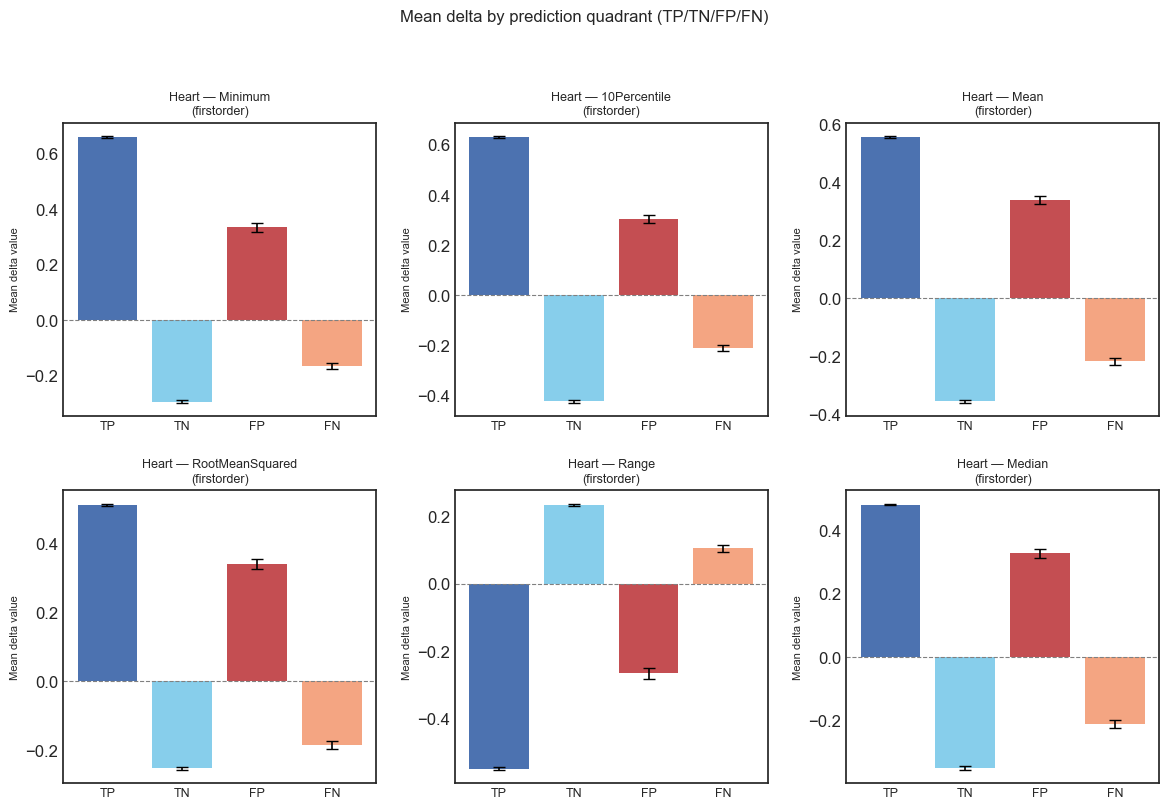

In [25]:
plot_delta_means_by_quadrant(df, top_features, n=6)

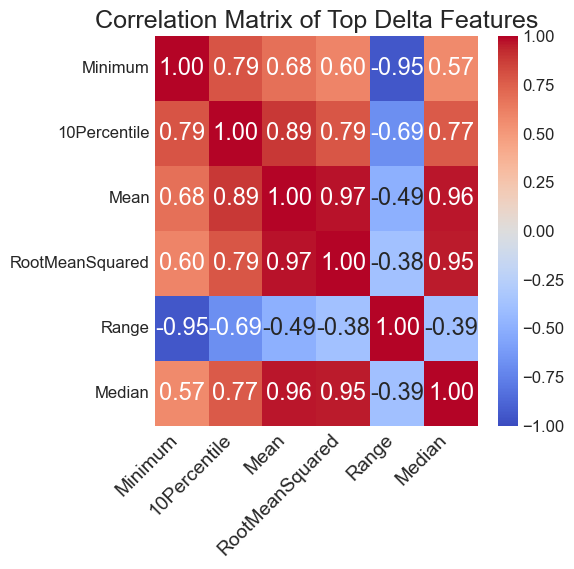

In [26]:
# Print the inter-correlation between the top 6 features
top_feature_names = top_features['feature'].tolist()
correlation_matrix = df[top_feature_names].corr()

#names are too big, just use the last word  after the last underscore for the labels
correlation_matrix.columns = [col.split('_')[-1] for col in correlation_matrix.columns]
correlation_matrix.index   = [col.split('_')[-1] for col in correlation_matrix.index]

# top 6 only
correlation_matrix = correlation_matrix.iloc[:6, :6]

plt.figure(figsize=(6, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Top Delta Features')
# tilt the x labels for better readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [27]:
def select_diverse_features(correlations_df, delta_cols, n=10, redundancy_threshold=0.7):
    # Sort candidates by absolute correlation with target (descending)
    ranked = correlations_df.sort_values('correlation', key=abs, ascending=False)
    candidates = ranked['feature'].tolist()

    # Pre-compute inter-feature correlation matrix (only on delta cols present in df)
    inter_corr = df[delta_cols].corr().abs()

    selected = []

    for candidate in candidates:
        if len(selected) == n:
            break

        if len(selected) == 0:
            # Always take the top-ranked feature first
            selected.append(candidate)
            continue

        # Check correlation of candidate against every already-selected feature
        max_redundancy = inter_corr.loc[candidate, selected].max()

        if max_redundancy < redundancy_threshold:
            selected.append(candidate)

    return selected

In [28]:
selected_features = select_diverse_features(correlations_df, delta_cols, n=10, redundancy_threshold=0.6)

In [29]:
selected_features

['delta_Heart_original_firstorder_Minimum',
 'delta_Heart_original_firstorder_RootMeanSquared',
 'delta_Right Lung_original_firstorder_Skewness',
 'delta_Heart_original_firstorder_Energy',
 'delta_Left Scapula_original_firstorder_Mean',
 'delta_Spine_area_pixels',
 'delta_Right Scapula_original_firstorder_90Percentile',
 'delta_Heart_original_firstorder_RobustMeanAbsoluteDeviation',
 'delta_Left Lung_area_pixels',
 'delta_Aorta_original_firstorder_MeanAbsoluteDeviation']

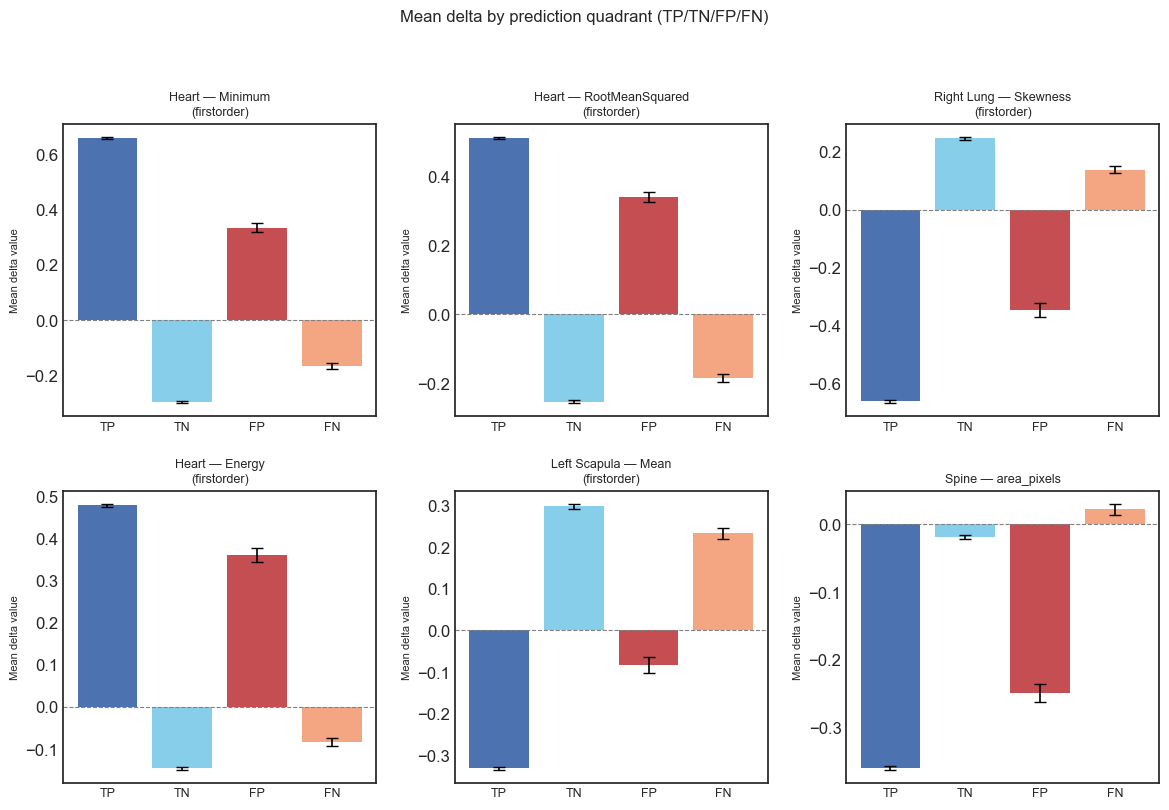

In [30]:
# Build a filtered top_features_df to pass into the plot function
diverse_top_features = correlations_df[correlations_df['feature'].isin(selected_features)].copy()
diverse_top_features['short_feature'] = (
    diverse_top_features['feature']
    .str.replace('delta_', '', regex=False)
    .str.replace('_original_', '', regex=False)
)
# Preserve selection order
diverse_top_features = diverse_top_features.set_index('feature').loc[selected_features].reset_index()

plot_delta_means_by_quadrant(df, diverse_top_features, n=6)

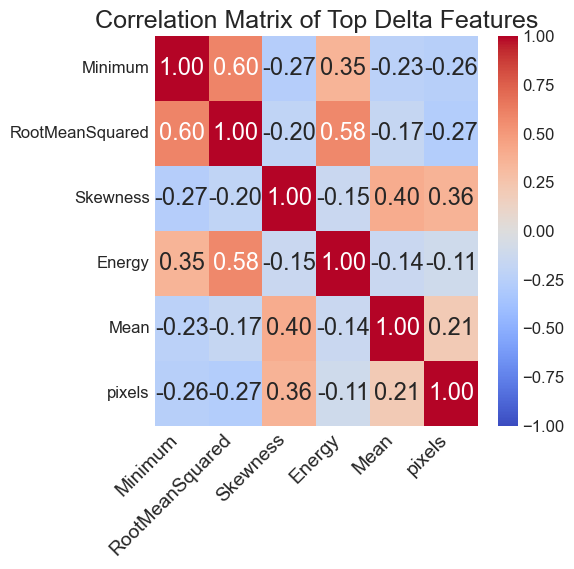

In [31]:
# Print the inter-correlation between the top 6 features
top_feature_names = diverse_top_features['feature'].tolist()
correlation_matrix = df[diverse_top_features['feature'].tolist()].corr()

#names are too big, just use the last word  after the last underscore for the labels
correlation_matrix.columns = [col.split('_')[-1] for col in correlation_matrix.columns]
correlation_matrix.index   = [col.split('_')[-1] for col in correlation_matrix.index]

# top 6 only
correlation_matrix = correlation_matrix.iloc[:6, :6]

plt.figure(figsize=(6, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Top Delta Features')
# tilt the x labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()